# Lesson 1.2 — Python for CFD

## Why Python?

CFD codes in production use Fortran, C++, or C. But for learning, Python is perfect:
the code reads like pseudocode, NumPy handles the heavy arithmetic, and Matplotlib gives
instant visual feedback. Once you understand the algorithm in Python, porting to a
compiled language is straightforward.

This lesson covers the exact Python patterns you will use throughout this curriculum.

---

## The CFD Array Model

In CFD, a physical field (velocity, pressure, temperature) is represented as an array
of values at discrete grid points. A 2D velocity field on a $50 \times 50$ grid is just a
`(50, 50)` NumPy array — one number per cell.

The key mental model: **array index = spatial location**.

```
u[j, i]  →  velocity at grid point (i*dx, j*dy)
             i = column index (x direction)
             j = row index    (y direction)
```

Array operations replace loops — this is called **vectorization**.


In [1]:
import numpy as np
import time

N = 500  # grid size

# Loop version (slow)
u = np.ones((N, N))
result_loop = np.zeros((N, N))

t0 = time.time()
for j in range(1, N-1):
    for i in range(1, N-1):
        result_loop[j, i] = u[j, i+1] - 2*u[j, i] + u[j, i-1]
t_loop = time.time() - t0

# Vectorized version (fast) — same computation using array slices
t0 = time.time()
result_vec = np.zeros((N, N))
result_vec[1:-1, 1:-1] = u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2]
t_vec = time.time() - t0

print(f"Loop version:       {t_loop*1000:.1f} ms")
print(f"Vectorized version: {t_vec*1000:.1f} ms")
print(f"Speedup: {t_loop/t_vec:.0f}x")
print(f"Results identical: {np.allclose(result_loop, result_vec)}")

Loop version:       105.9 ms
Vectorized version: 1.1 ms
Speedup: 101x
Results identical: True


## Array Slicing — The Heart of CFD Code

Almost every CFD operation is expressed as an array slice. The pattern is:

- `u[1:-1]` — all interior points (excludes first and last)
- `u[2:]`  — all points shifted one step to the right (neighbour to the right)
- `u[:-2]` — all points shifted one step to the left (neighbour to the left)

This maps directly to finite-difference stencils. The central difference approximation to
$\frac{\partial^2 u}{\partial x^2}$ at interior point $i$ is:

$$\frac{\partial^2 u}{\partial x^2}\bigg|_i \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}$$

In NumPy this is a single line:
```python
d2u_dx2[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
```

Master this pattern — you will write it hundreds of times.


N=  10  dx=0.6981  max error=3.94e-02
N=  20  dx=0.3307  max error=9.05e-03
N=  50  dx=0.1282  max error=1.37e-03
N= 200  dx=0.0316  max error=8.31e-05


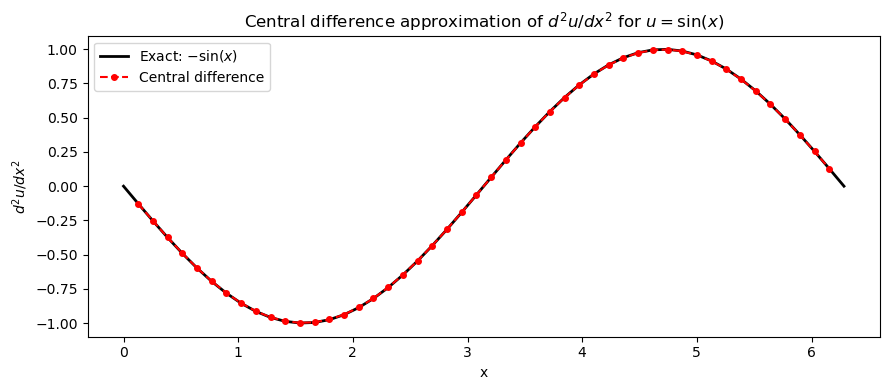

In [2]:
import matplotlib.pyplot as plt

# Demonstrate central difference for d²/dx² on u(x) = sin(x)
# Exact: d²sin(x)/dx² = -sin(x)

for N in [10, 20, 50, 200]:
    x = np.linspace(0, 2*np.pi, N)
    dx = x[1] - x[0]
    u = np.sin(x)
    
    # Central difference
    d2u = np.zeros_like(u)
    d2u[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    
    exact = -np.sin(x)
    error = np.max(np.abs(d2u[1:-1] - exact[1:-1]))
    print(f"N={N:4d}  dx={dx:.4f}  max error={error:.2e}")

# Visualize for N=50
N = 50
x = np.linspace(0, 2*np.pi, N)
dx = x[1] - x[0]
u = np.sin(x)
d2u = np.zeros_like(u)
d2u[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2

plt.figure(figsize=(9, 4))
plt.plot(x, -np.sin(x), 'k-', linewidth=2, label='Exact: $-\\sin(x)$')
plt.plot(x[1:-1], d2u[1:-1], 'ro--', markersize=4, label='Central difference')
plt.xlabel('x')
plt.ylabel('$d^2u/dx^2$')
plt.title('Central difference approximation of $d^2u/dx^2$ for $u = \\sin(x)$')
plt.legend()
plt.tight_layout()
plt.show()

## Building a Grid

A CFD grid is just a set of uniformly-spaced coordinates. In 2D, `np.meshgrid` generates
the coordinate arrays:


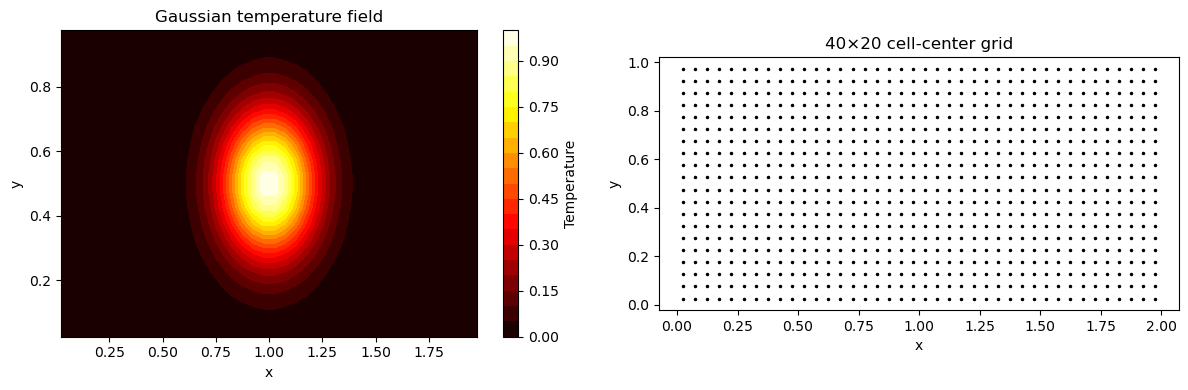

Grid shape: (20, 40)  |  dx=0.050  dy=0.050
T array shape: (20, 40)
T max at: (0.98, 0.52)


In [3]:
# Standard 2D grid setup used throughout this curriculum
Lx, Ly = 2.0, 1.0   # domain size
nx, ny = 40, 20      # number of cells

dx = Lx / nx
dy = Ly / ny

# Cell-center coordinates
x = np.linspace(0.5*dx, Lx - 0.5*dx, nx)
y = np.linspace(0.5*dy, Ly - 0.5*dy, ny)
X, Y = np.meshgrid(x, y)  # shape: (ny, nx)

# Initialize a field: Gaussian temperature bump
T = np.exp(-((X - 1.0)**2 + (Y - 0.5)**2) / 0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Filled contour
cf = axes[0].contourf(X, Y, T, levels=20, cmap='hot')
plt.colorbar(cf, ax=axes[0], label='Temperature')
axes[0].set_title('Gaussian temperature field')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Show grid points
axes[1].plot(X.ravel(), Y.ravel(), 'k.', markersize=3)
axes[1].set_title(f'{nx}×{ny} cell-center grid')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Grid shape: {X.shape}  |  dx={dx:.3f}  dy={dy:.3f}")
print(f"T array shape: {T.shape}")
print(f"T max at: ({X.ravel()[T.argmax()]:.2f}, {Y.ravel()[T.argmax()]:.2f})")

## Essential Matplotlib Patterns for CFD

You'll use these visualization calls constantly:

| Plot type | When to use | Call |
|-----------|-------------|------|
| `contourf` | Scalar fields (pressure, temperature) | `ax.contourf(X, Y, field)` |
| `streamplot` | Velocity field | `ax.streamplot(X, Y, U, V)` |
| `quiver` | Sparse velocity arrows | `ax.quiver(X, Y, U, V)` |
| `plot` | Convergence history, 1D profiles | `ax.plot(x, y)` |
| `semilogy` | Residuals (span many decades) | `ax.semilogy(iters, res)` |


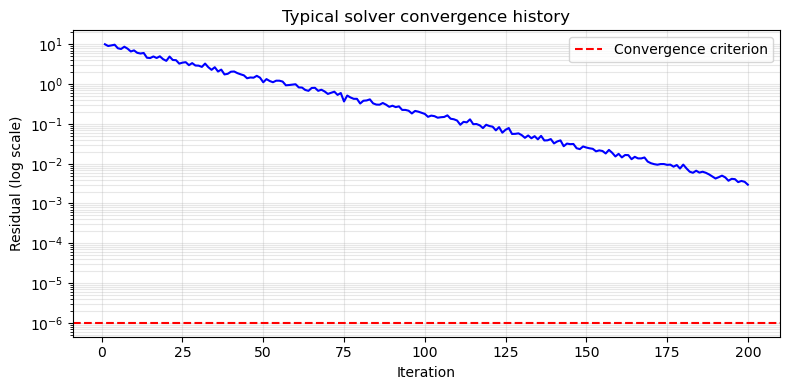

IndexError: index 0 is out of bounds for axis 0 with size 0

In [4]:
# Convergence residual plot — you'll see this a lot in iterative solvers
np.random.seed(42)
iterations = np.arange(1, 201)
# Simulated residual: exponential decay with some noise
residual = 10.0 * np.exp(-iterations * 0.04) * (1 + 0.1 * np.random.randn(200))
residual = np.maximum(residual, 1e-8)  # floor at machine precision

plt.figure(figsize=(8, 4))
plt.semilogy(iterations, residual, 'b-', linewidth=1.5)
plt.axhline(1e-6, color='r', linestyle='--', label='Convergence criterion')
plt.xlabel('Iteration')
plt.ylabel('Residual (log scale)')
plt.title('Typical solver convergence history')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

conv_iter = iterations[residual < 1e-6][0]
print(f"Converged at iteration {conv_iter} (residual < 1e-6)")

## Key Takeaways

- CFD fields are NumPy arrays; grid index $i$ corresponds to spatial position $x_i = i \cdot \Delta x$.
- Vectorized array slicing replaces nested loops — 10–100× faster.
- The slice pattern `u[2:] - 2*u[1:-1] + u[:-2]` is the central-difference Laplacian. Memorise it.
- Always visualize with `contourf` + `streamplot`; use `semilogy` for convergence history.

---

**Next**: Lesson 1.3 — Conservation Laws (mass, momentum, energy) — the physical foundation of CFD.
